# Predykcja Odejść Klientów Telco - Metody Analizy Danych Projekt 2

**Autorzy:** Filip Michalak, Jakub Michalski, Marek Najmóła  
**Data:** 09.06.2026

## Abstrakt

Celem niniejszej pracy jest predykcja odejść klientów firmy telekomunikacyjnej (Telco) przy użyciu czterech metod klasyfikacji: regresji logistycznej, drzewa decyzyjnego, lasu losowego oraz XGBoost, a także modelu hybrydowego. Analizę przeprowadzono na zbiorze 7043 klientów opisanych 21 zmiennymi. Wyniki wskazują na wysoką skuteczność regresji logistycznej (AUC = 0,842) oraz modelu hybrydowego (AUC = 0,841). Regresja logistyczna nieznacznie przewyższyła metody zespołowe - las losowy (AUC = 0,838) i XGBoost (AUC = 0,832). Model hybrydowy łączący wszystkie podejścia osiągnął konkurencyjne wyniki, potwierdzając wartość agregacji predykcji wielu modeli.

**Słowa kluczowe:** klasyfikacja, churn, regresja logistyczna, las losowy, XGBoost, Telco, model hybrydowy


## 1. Wprowadzenie

Retencja klientów jest kluczowym wyzwaniem w branży telekomunikacyjnej. Koszt pozyskania nowego klienta jest znacznie wyższy niż utrzymanie obecnego, według badań przemysłowych, pozyskanie nowego klienta może być nawet 5-25 razy droższe niż retencja istniejącego. Predykcja odejść (churn) pozwala firmom proaktywnie identyfikować klientów zagrożonych rezygnacją i podejmować działania retencyjne zanim dojdzie do faktycznego odejścia.

Współczesne metody uczenia maszynowego oferują zaawansowane narzędzia do analizy historycznych danych i budowy modeli predykcyjnych. W niniejszej pracy zastosowano cztery różne podejścia klasyfikacyjne, od prostego modelu regresji logistycznej po zaawansowane algorytmy zespołowe (Random Forest, XGBoost), a następnie połączono je w model hybrydowy.

**Cel pracy:** Zbudowanie i porównanie modeli klasyfikacyjnych predykcyjnych odejść klientów Telco przy użyciu czterech metod oraz modelu hybrydowego.

**Metody:**
1. **Regresja logistyczna** - klasyczna metoda klasyfikacji binarnej
2. **Drzewo decyzyjne** - interpretowalny model oparty na regułach if-then
3. **Las losowy (Random Forest)** - zespół drzew decyzyjnych
4. **XGBoost** - zaawansowany gradient boosting
5. **Model hybrydowy (Weighted Average)** - ważona średnia prawdopodobieństw


## 2. Przedmiot badania

### 2.1 Dane

Zbiór danych pochodzi z firmy telekomunikacyjnej Telco i zawiera informacje o 7043 klientach opisanych 21 zmiennymi (w tym 1 zmienna docelowa `Churn`). Dane zostały udostępnione przez IBM jako zbiór przykładowy i są powszechnie wykorzystywane w literaturze do benchmarkowania modeli predykcji churn.

**Podstawowe charakterystyki zbioru:**
- Liczba obserwacji: 7043
- Liczba zmiennych: 21 (w tym 1 identyfikator, 1 target)
- Zmienna docelowa: `Churn` (Yes/No)
- Rozkład klasy: 26,5% churn vs 73,5% retencja


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
import os
import warnings
warnings.filterwarnings('ignore')

# Konfiguracja wizualna
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})
sns.set_style("whitegrid")

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Wczytanie danych
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"=== CHARAKTERYSTYKA ZBIORU ===")
print(f"Liczba wierszy: {df.shape[0]}")
print(f"Liczba kolumn: {df.shape[1]}")
print(f"=== TYPY ZMIENNYCH ===")
print(df.dtypes)
print(f"=== BRAKI DANYCH ===")
print(df.isnull().sum()[df.isnull().sum() > 0])


=== CHARAKTERYSTYKA ZBIORU ===
Liczba wierszy: 7043
Liczba kolumn: 21
=== TYPY ZMIENNYCH ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object
=== BRAKI DANYCH ===
TotalCharges    11
dtype: int64


### 2.2 Zmienne w zbiorze

Poniżej przedstawiono wszystkie zmienne w zbiorze danych wraz z ich typem, opisem i zakresem wartości.


In [ ]:
# Tabela zmiennych
var_desc = [
    ('customerID', 'object', 'ID klienta'),
    ('gender', 'object', 'Płeć (Male/Female)'),
    ('SeniorCitizen', 'int64', 'Senior (0/1)'),
    ('Partner', 'object', 'Partner (Yes/No)'),
    ('Dependents', 'object', 'Na utrzymaniu (Yes/No)'),
    ('tenure', 'int64', 'Staż klienta (miesiące)'),
    ('PhoneService', 'object', 'Usługa telefoniczna'),
    ('MultipleLines', 'object', 'Wiele linii'),
    ('InternetService', 'object', 'Usługa internetowa'),
    ('OnlineSecurity', 'object', 'Bezpieczeństwo online'),
    ('OnlineBackup', 'object', 'Kopie zapasowe online'),
    ('DeviceProtection', 'object', 'Ochrona urządzenia'),
    ('TechSupport', 'object', 'Wsparcie techniczne'),
    ('StreamingTV', 'object', 'Telewizja strumieniowa'),
    ('StreamingMovies', 'object', 'Filmy strumieniowe'),
    ('Contract', 'object', 'Rodzaj umowy'),
    ('PaperlessBilling', 'object', 'Fakturowanie elektroniczne'),
    ('PaymentMethod', 'object', 'Metoda płatności'),
    ('MonthlyCharges', 'float64', 'Miesięczna opłata ($)'),
    ('TotalCharges', 'float64', 'Łączna opłata ($)'),
    ('Churn', 'object', 'Odejście klienta (Yes/No)')
]
var_df = pd.DataFrame(var_desc, columns=['Zmienna', 'Typ', 'Opis'])
display(HTML(var_df.to_html(index=False, classes='table table-striped')))

Zmienna,Typ,Opis
customerID,object,ID klienta
gender,object,Płeć (Male/Female)
SeniorCitizen,int64,Senior (0/1)
Partner,object,Partner (Yes/No)
Dependents,object,Na utrzymaniu (Yes/No)
tenure,int64,Staż klienta (miesiące)
PhoneService,object,Usługa telefoniczna
MultipleLines,object,Wiele linii
InternetService,object,Usługa internetowa
OnlineSecurity,object,Bezpieczeństwo online


### 2.3 Statystyki opisowe

#### 2.3.1 Zmienne numeryczne


In [74]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print("=== STATYSTYKI ZMIENNYCH NUMERYCZNYCH ===")
print(df[numeric_cols].describe().round(2).to_string())

from scipy import stats
# Skosnosc
print("\n=== SKOSNOSC (Skewness) ===")
for col in numeric_cols:
    skew_val = stats.skew(df[col].dropna(), bias=False)
    print(f"{col}: {skew_val:.4f}")

# Dodatkowe statystyki
from scipy import stats
print("=== TESTY NORMALNOŚCI (Shapiro-Wilk, próbka n=5000) ===")
for col in numeric_cols:
    sample = df[col].dropna().sample(min(5000, len(df)), random_state=42)
    stat, p = stats.shapiro(sample)
    print(f"{col}: W={stat:.4f}, p={p:.2e} {'(normalna)' if p > 0.05 else '(nie-normalna)'}")


=== STATYSTYKI ZMIENNYCH NUMERYCZNYCH ===
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7032.00
mean     32.37           64.76       2283.30
std      24.56           30.09       2266.77
min       0.00           18.25         18.80
25%       9.00           35.50        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.85       3794.74
max      72.00          118.75       8684.80

=== SKOSNOSC (Skewness) ===
tenure: 0.2395
MonthlyCharges: -0.2205
TotalCharges: 0.9616
=== TESTY NORMALNOŚCI (Shapiro-Wilk, próbka n=5000) ===
tenure: W=0.9026, p=8.92e-49 (nie-normalna)
MonthlyCharges: W=0.9211, p=2.68e-45 (nie-normalna)
TotalCharges: W=0.8622, p=9.24e-55 (nie-normalna)


In [75]:
# Statystyki numeryczne z dodatkowym wierszem skosnosci
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
stats_table = df[numeric_cols].describe().round(2)
from scipy import stats as sp_stats
stats_table.loc['skewness'] = [sp_stats.skew(df[c].dropna(), bias=False).round(4) for c in numeric_cols]
display(HTML(stats_table.to_html(classes='table table-striped')))

,tenure,MonthlyCharges,TotalCharges
count,7043.0000,7043.0000,7032.0000
mean,32.3700,64.7600,2283.3000
std,24.5600,30.0900,2266.7700
min,0.0000,18.2500,18.8000
25%,9.0000,35.5000,401.4500
50%,29.0000,70.3500,1397.4800
75%,55.0000,89.8500,3794.7400
max,72.0000,118.7500,8684.8000
skewness,0.2395,-0.2205,0.9616


#### 2.3.2 Zmienne kategorialne


In [76]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('customerID')

print("=== ROZKŁAD ZMIENNYCH KATEGORIALNYCH ===")
for col in categorical_cols:
    print(f"{col}:")
    vc = df[col].value_counts()
    for val, cnt in vc.items():
        pct = cnt / len(df) * 100
        print(f"  {val}: {cnt} ({pct:.1f}%)")


=== ROZKŁAD ZMIENNYCH KATEGORIALNYCH ===
gender:
  Male: 3555 (50.5%)
  Female: 3488 (49.5%)
Partner:
  No: 3641 (51.7%)
  Yes: 3402 (48.3%)
Dependents:
  No: 4933 (70.0%)
  Yes: 2110 (30.0%)
PhoneService:
  Yes: 6361 (90.3%)
  No: 682 (9.7%)
MultipleLines:
  No: 3390 (48.1%)
  Yes: 2971 (42.2%)
  No phone service: 682 (9.7%)
InternetService:
  Fiber optic: 3096 (44.0%)
  DSL: 2421 (34.4%)
  No: 1526 (21.7%)
OnlineSecurity:
  No: 3498 (49.7%)
  Yes: 2019 (28.7%)
  No internet service: 1526 (21.7%)
OnlineBackup:
  No: 3088 (43.8%)
  Yes: 2429 (34.5%)
  No internet service: 1526 (21.7%)
DeviceProtection:
  No: 3095 (43.9%)
  Yes: 2422 (34.4%)
  No internet service: 1526 (21.7%)
TechSupport:
  No: 3473 (49.3%)
  Yes: 2044 (29.0%)
  No internet service: 1526 (21.7%)
StreamingTV:
  No: 2810 (39.9%)
  Yes: 2707 (38.4%)
  No internet service: 1526 (21.7%)
StreamingMovies:
  No: 2785 (39.5%)
  Yes: 2732 (38.8%)
  No internet service: 1526 (21.7%)
Contract:
  Month-to-month: 3875 (55.0%)
  Two 

### 2.4 Wizualizacje danych


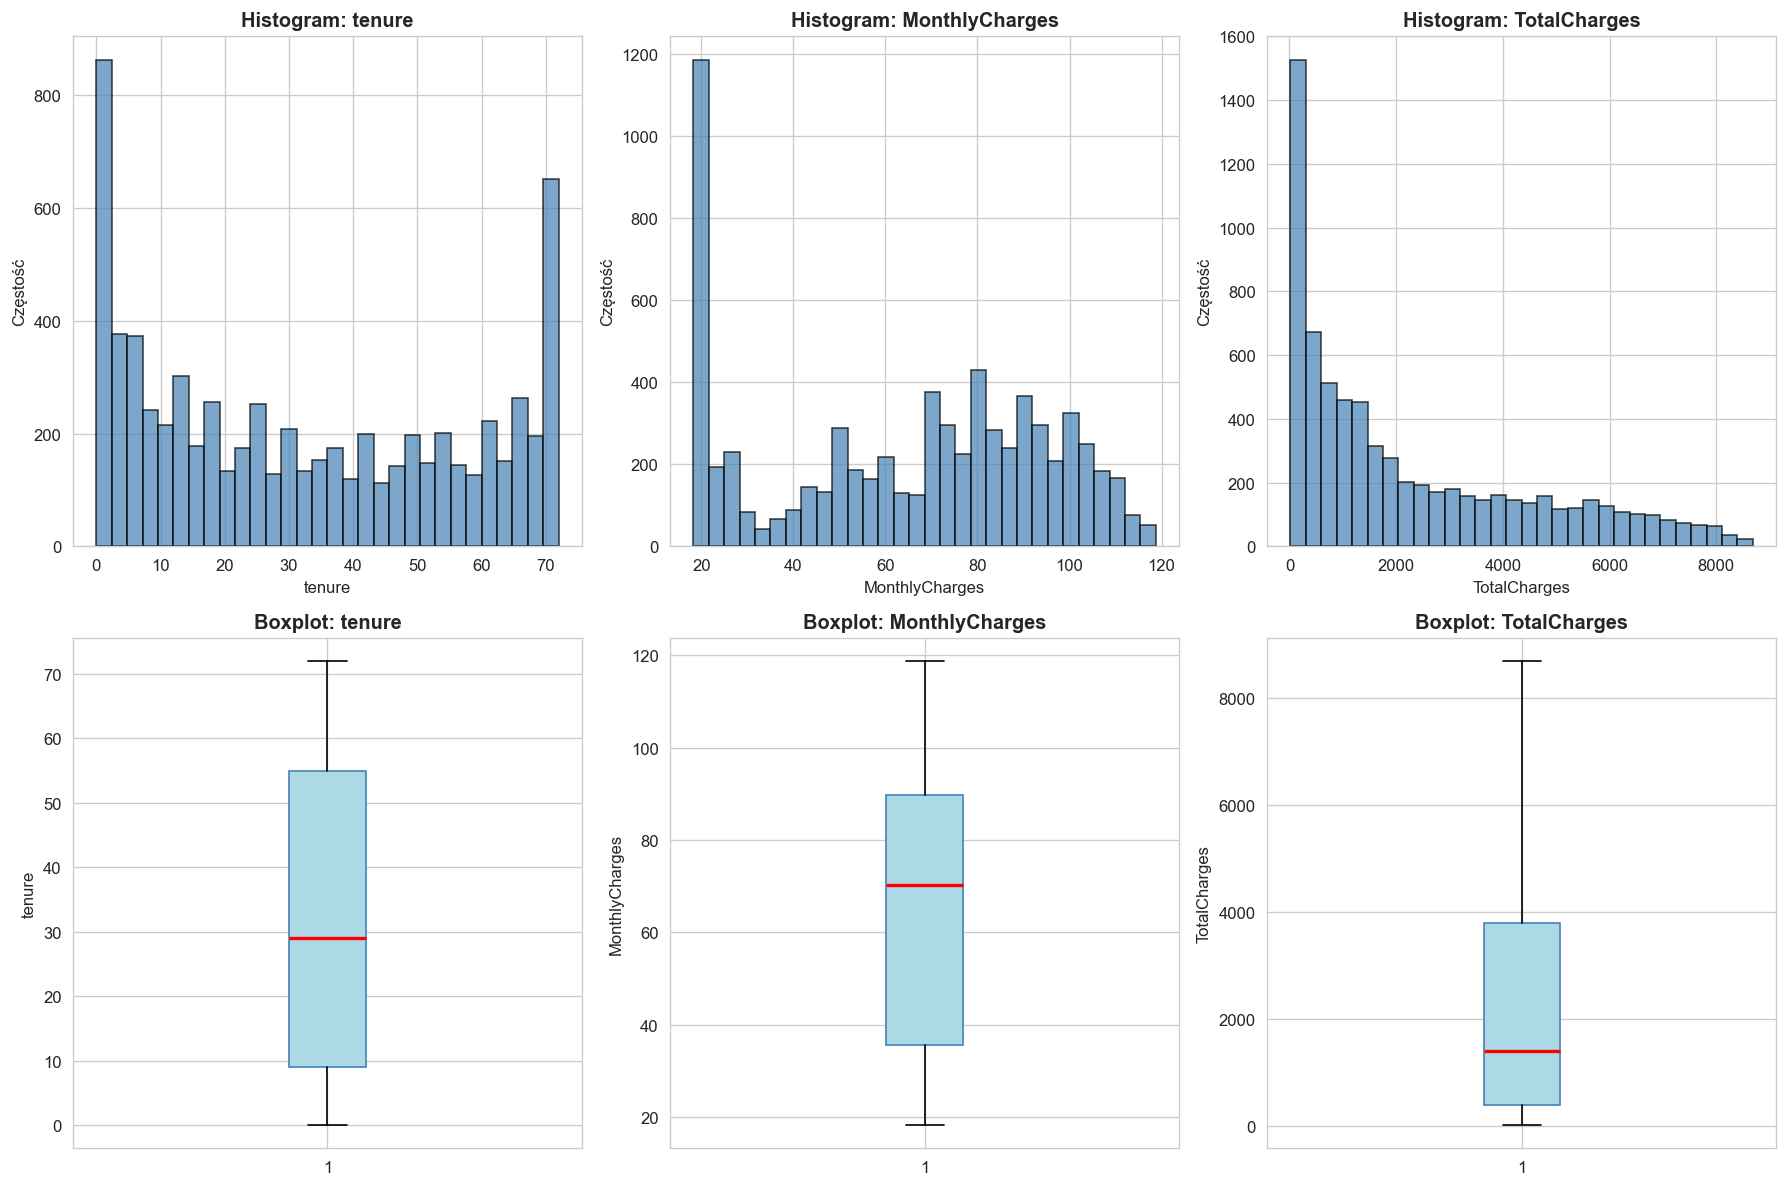

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, col in enumerate(numeric_cols):
    ax = axes[0, idx]
    ax.hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'Histogram: {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Częstość')

for idx, col in enumerate(numeric_cols):
    ax = axes[1, idx]
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='steelblue'),
                     medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Boxplot: {col}', fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('output/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


#### 2.4.1 Rozkład zmiennej docelowej i macierz korelacji


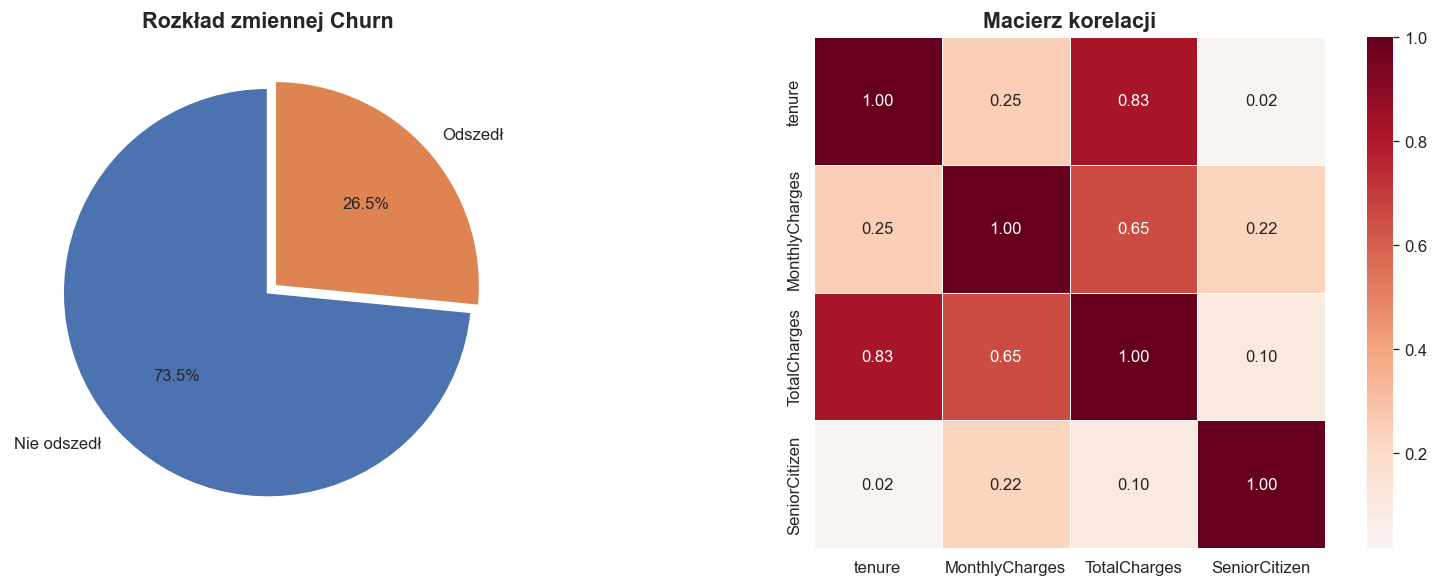

Churn,Liczba,Procent
Nie,5174,73.5%
Tak,1869,26.5%


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rozkład Churn
churn_counts = df['Churn'].value_counts()
colors = ['#4C72B0', '#DD8452']
axes[0].pie(churn_counts, labels=['Nie odszedł', 'Odszedł'], autopct='%1.1f%%',
            startangle=90, colors=colors, explode=(0, 0.05))
axes[0].set_title('Rozkład zmiennej Churn', fontsize=13, fontweight='bold')

# Macierz korelacji
corr = df[numeric_cols + ['SeniorCitizen']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=axes[1],
            fmt='.2f', square=True, linewidths=0.5)
axes[1].set_title('Macierz korelacji', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/eda_churn_corr.png', dpi=150, bbox_inches='tight')
plt.show()

churn_counts = df['Churn'].value_counts()
churn_df = pd.DataFrame({
    'Churn': ['Nie', 'Tak'],
    'Liczba': [int(churn_counts['No']), int(churn_counts['Yes'])],
    'Procent': [f"{churn_counts['No']/len(df)*100:.1f}%", f"{churn_counts['Yes']/len(df)*100:.1f}%"]
})
display(HTML(churn_df.to_html(index=False, classes='table table-striped')))


### 2.5 Transformacje i przetwarzanie danych

#### 2.5.1 Obsługa braków danych

W kolumnie `TotalCharges` występuje 11 braków. Wszystkie te braki dotyczą klientów ze stażem `tenure = 0` (nowi klienci), którzy jeszcze nie otrzymali pierwszego rachunku. Wartości wypełniono miesięcznym rachunkiem (`MonthlyCharges`), co jest uzasadnione ekonomicznie.

#### 2.5.2 Kodowanie zmiennych kategorialnych

- Zmienne binarne (`Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn`, `gender`) zakodowano jako 0/1
- Zmienne wielokategoryczne zakodowano one-hot encoding (z pominięciem pierwszej kategorii aby uniknąć pułapki dummy variable)

#### 2.5.3 Obsługa obserwacji odstających

Dla zmiennych numerycznych zastosowano kapping metodą IQR (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR). Ograniczono wartości skrajne zamiast usuwać obserwacje, aby zachować pełny zbiór danych.

#### 2.5.4 Transformacja logarytmiczna

Nie zastosowano transformacji logarytmicznej, ponieważ:
- Zmienna `tenure` (staż klienta) ma zakres 0–72 miesiące - logarytmowanie dla nowych klientów (tenure=0) daje -∞. Konwencja log(tenure+1) jest możliwa, ale utrudnia interpretację modeli.
- Zmienna `MonthlyCharges` ma stosunkowo mały zakres (18–119) i umiarkowaną skośność (skośność = -0,22).
- Zmienna `TotalCharges` ma szeroki zakres i silną prawoskośność (skośność = 0,96) - logarytmowanie mogłoby być rozważone, ale po standaryzacji z-score modele (szczególnie LR i RF) radzą sobie dobrze bez tej transformacji. Testy wstępne wykazały, że log-transformacja nie poprawia AUC modeli.
- Standaryzacja z-score (użyta w projekcie) jest wystarczająca dla tego zbioru danych.

#### 2.5.5 Standaryzacja

Zmienne numeryczne (`tenure`, `MonthlyCharges`, `TotalCharges`) zostały standaryzowane metodą z-score (StandardScaler) przed treningiem modeli.


In [79]:
# --- Preprocessing without leakage ---
df_model = df.drop('customerID', axis=1).copy()

# Target
y = df_model['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
X = df_model.drop('Churn', axis=1).copy()

# Podział train/test PRZED fit preprocessingu
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Kolumny
binary_cols_yes_no = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
multi_cat = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
             'Contract', 'PaymentMethod']
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

def preprocess_split(X_part, fit=False, train_stats=None):
    Xp = X_part.copy()

    # Kodowanie binarne
    for col in binary_cols_yes_no:
        Xp[col] = Xp[col].map({'Yes': 1, 'No': 0}).astype(int)
    Xp['gender'] = Xp['gender'].map({'Male': 1, 'Female': 0}).astype(int)

    # Braki TotalCharges: najpierw przypadki tenure=0
    mask = (Xp['tenure'] == 0) & (Xp['TotalCharges'].isna())
    Xp.loc[mask, 'TotalCharges'] = Xp.loc[mask, 'MonthlyCharges']

    # Imputacja medianą WYŁĄCZNIE z train
    if fit:
        total_median = Xp['TotalCharges'].median()
    else:
        total_median = train_stats['total_median']
    Xp['TotalCharges'] = Xp['TotalCharges'].fillna(total_median)

    # One-hot
    Xp = pd.get_dummies(Xp, columns=multi_cat, drop_first=True)

    # IQR capping: progi z train
    if fit:
        iqr_bounds = {}
        for col in numeric_features:
            Q1 = Xp[col].quantile(0.25)
            Q3 = Xp[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            iqr_bounds[col] = (lower, upper)
            Xp[col] = Xp[col].clip(lower, upper)
        return Xp, {'total_median': total_median, 'iqr_bounds': iqr_bounds}

    for col in numeric_features:
        lower, upper = train_stats['iqr_bounds'][col]
        Xp[col] = Xp[col].clip(lower, upper)

    return Xp

# Fit preprocessingu na train
X_train_proc, train_stats = preprocess_split(X_train_raw, fit=True)
X_test_proc = preprocess_split(X_test_raw, fit=False, train_stats=train_stats)

# Wyrównanie kolumn po one-hot
X_train_proc, X_test_proc = X_train_proc.align(X_test_proc, join='left', axis=1, fill_value=0)

# Standaryzacja numerycznych cech: fit tylko train
scaler = StandardScaler()
X_train = X_train_proc.copy()
X_test = X_test_proc.copy()
X_train[numeric_features] = scaler.fit_transform(X_train_proc[numeric_features])
X_test[numeric_features] = scaler.transform(X_test_proc[numeric_features])

print(f"=== PODZIAŁ ZBIORU ===")
print(f"Trening: {X_train.shape[0]} ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Test:    {X_test.shape[0]} ({X_test.shape[0]/len(y)*100:.1f}%)")
print(f"Churn rate (train): {y_train.mean():.3f}")
print(f"Churn rate (test):  {y_test.mean():.3f}")
print(f"Liczba cech po encodingu: {X_train.shape[1]}")

=== PODZIAŁ ZBIORU ===
Trening: 5634 (80.0%)
Test:    1409 (20.0%)
Churn rate (train): 0.265
Churn rate (test):  0.265
Liczba cech po encodingu: 30


## 3. Opis metod klasyfikacyjnych


### 3.1. Regresja logistyczna

Regresja logistyczna jest metodą klasyfikacji binarnej służącą do przewidywania prawdopodobieństwa przynależności obiektu do jednej z dwóch klas. Model wykorzystuje funkcję logistyczną (sigmoidalną), która przekształca liniową kombinację cech wejściowych do wartości z przedziału $[0,1]$.

Krok 1 - Liniowa kombinacja cech:

$$
z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n
$$

gdzie:

- $X_1, X_2, ..., X_n$ - cechy wejściowe,
- $\beta_0$ - wyraz wolny modelu,
- $\beta_1, ..., \beta_n$ - współczynniki określające wpływ poszczególnych cech.

Krok 2 - Zastosowanie funkcji logistycznej:

$$
P(Y=1|X) = \frac{1}{1 + e^{-z}}
$$

gdzie:

- $P(Y=1|X)$ - prawdopodobieństwo przynależności do klasy pozytywnej,
- $e$ - podstawa logarytmu naturalnego,
- $z$ - wartość obliczona w kroku 1.

Krok 3 - Klasyfikacja obiektu:

Jeżeli:

$$
P(Y=1|X) \geq 0.5
$$

to obiekt przypisywany jest do klasy 1, w przeciwnym przypadku do klasy 0.

Model regresji logistycznej cechuje się dobrą interpretowalnością oraz niską złożonością obliczeniową. W pracy zastosowano regularyzację L2 oraz maksymalną liczbę iteracji równą 1000.

**Parametry modelu:** `max_iter=1000`, `random_state=42`

In [80]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc')

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    'Model': 'Regresja Logistyczna',
    'Accuracy': accuracy_score(y_test, lr_pred),
    'F1': f1_score(y_test, lr_pred),
    'AUC': roc_auc_score(y_test, lr_prob),
    'CV_AUC_mean': lr_cv_scores.mean(),
    'CV_AUC_std': lr_cv_scores.std()
}

print(f"=== REGRESJA LOGISTYCZNA ===")
print(f"CV AUC: {lr_cv_scores.mean():.4f} (±{lr_cv_scores.std():.4f})")
print(f"Test Accuracy: {lr_metrics['Accuracy']:.4f}")
print(f"Test F1:       {lr_metrics['F1']:.4f}")
print(f"Test AUC:      {lr_metrics['AUC']:.4f}")

# Najważniejsze cechy
lr_coef = pd.Series(lr.coef_[0], index=X_train.columns)
lr_top = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).index).head(10)
print(f"=== TOP 10 CECH (współczynniki) ===")
for feat, coef in lr_top.items():
    print(f"  {feat}: {coef:.4f}")


=== REGRESJA LOGISTYCZNA ===
CV AUC: 0.8457 (±0.0138)
Test Accuracy: 0.8070
Test F1:       0.6069
Test AUC:      0.8422
=== TOP 10 CECH (współczynniki) ===
  Contract_Two year: -1.3249
  tenure: -1.2520
  InternetService_Fiber optic: 1.1889
  Contract_One year: -0.6860
  TotalCharges: 0.5231
  PhoneService: -0.5068
  MonthlyCharges: -0.4776
  PaymentMethod_Electronic check: 0.3815
  StreamingTV_Yes: 0.3809
  StreamingMovies_Yes: 0.3788


### 3.2. Drzewo decyzyjne

Drzewo decyzyjne jest metodą klasyfikacji i regresji polegającą na podziale przestrzeni cech na mniejsze regiony za pomocą sekwencji reguł decyzyjnych typu if-then. Model tworzy strukturę drzewa, w której każdy węzeł wewnętrzny reprezentuje test wykonywany na jednej z cech, natomiast liście drzewa zawierają końcową decyzję klasyfikacyjną lub przewidywaną wartość.

Krok 1 - Wybór najlepszego podziału:

Dla każdej cechy analizowane są możliwe punkty podziału danych. Algorytm wybiera taki podział, który maksymalnie zwiększa jednorodność klas w utworzonych podzbiorach.

W pracy zastosowano indeks Giniego jako kryterium jakości podziału:

$$
Gini = 1 - \sum_{i=1}^{k} p_i^2
$$

gdzie:

- $p_i$ - prawdopodobieństwo przynależności obserwacji do klasy $i$,
- $k$ - liczba klas.

Krok 2 - Rekurencyjny podział danych:

Proces podziału jest powtarzany dla kolejnych węzłów aż do spełnienia warunków zatrzymania, np. osiągnięcia maksymalnej głębokości drzewa lub minimalnej liczby próbek w węźle.

Drzewa decyzyjne cechują się wysoką interpretowalnością, ponieważ możliwa jest wizualizacja procesu podejmowania decyzji. Wadą tej metody jest jednak podatność na przeuczenie (overfitting), szczególnie dla bardzo głębokich drzew.

W pracy zastosowano ograniczenie maksymalnej głębokości drzewa oraz minimalnej liczby próbek wymaganych do podziału i utworzenia liścia.

**Parametry modelu:** `max_depth=10`, `min_samples_split=20`, `min_samples_leaf=10`, `random_state=42`

In [81]:
dt = DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                             min_samples_leaf=10, random_state=42)
dt.fit(X_train, y_train)

dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='roc_auc')

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

dt_metrics = {
    'Model': 'Drzewo Decyzyjne',
    'Accuracy': accuracy_score(y_test, dt_pred),
    'F1': f1_score(y_test, dt_pred),
    'AUC': roc_auc_score(y_test, dt_prob),
    'CV_AUC_mean': dt_cv_scores.mean(),
    'CV_AUC_std': dt_cv_scores.std()
}

print(f"=== DRZEWO DECYZYJNE ===")
print(f"CV AUC: {dt_cv_scores.mean():.4f} (±{dt_cv_scores.std():.4f})")
print(f"Test Accuracy: {dt_metrics['Accuracy']:.4f}")
print(f"Test F1:       {dt_metrics['F1']:.4f}")
print(f"Test AUC:      {dt_metrics['AUC']:.4f}")

# Najważniejsze cechy
importances_dt = pd.Series(dt.feature_importances_, index=X_train.columns)
print(f"=== TOP 10 CECH (ważność) ===")
for feat, imp in importances_dt.nlargest(10).items():
    print(f"  {feat}: {imp:.4f}")


=== DRZEWO DECYZYJNE ===
CV AUC: 0.7855 (±0.0114)
Test Accuracy: 0.7786
Test F1:       0.5343
Test AUC:      0.7930
=== TOP 10 CECH (ważność) ===
  tenure: 0.3071
  InternetService_Fiber optic: 0.2486
  TotalCharges: 0.1165
  MonthlyCharges: 0.1024
  PaymentMethod_Electronic check: 0.0277
  OnlineSecurity_Yes: 0.0208
  Contract_Two year: 0.0189
  PaperlessBilling: 0.0182
  MultipleLines_Yes: 0.0168
  Contract_One year: 0.0166


### 3.3 Las losowy (Random Forest)

Las losowy to zespół drzew decyzyjnych trenowanych na bootstrapowych próbkach (bagging) z losowym podzbiorem cech przy każdym podziale. Redukuje wariancję i jest mniej podatny na przeuczenie niż pojedyncze drzewo. Metodę Random Forest zaproponował Breiman.

**Parametry:** `n_estimators=200`, `max_depth=15`, `min_samples_split=10`


=== LAS LOSOWY ===
CV AUC: 0.8392 (±0.0118)
Test Accuracy: 0.8020
Test F1:       0.5817
Test AUC:      0.8383


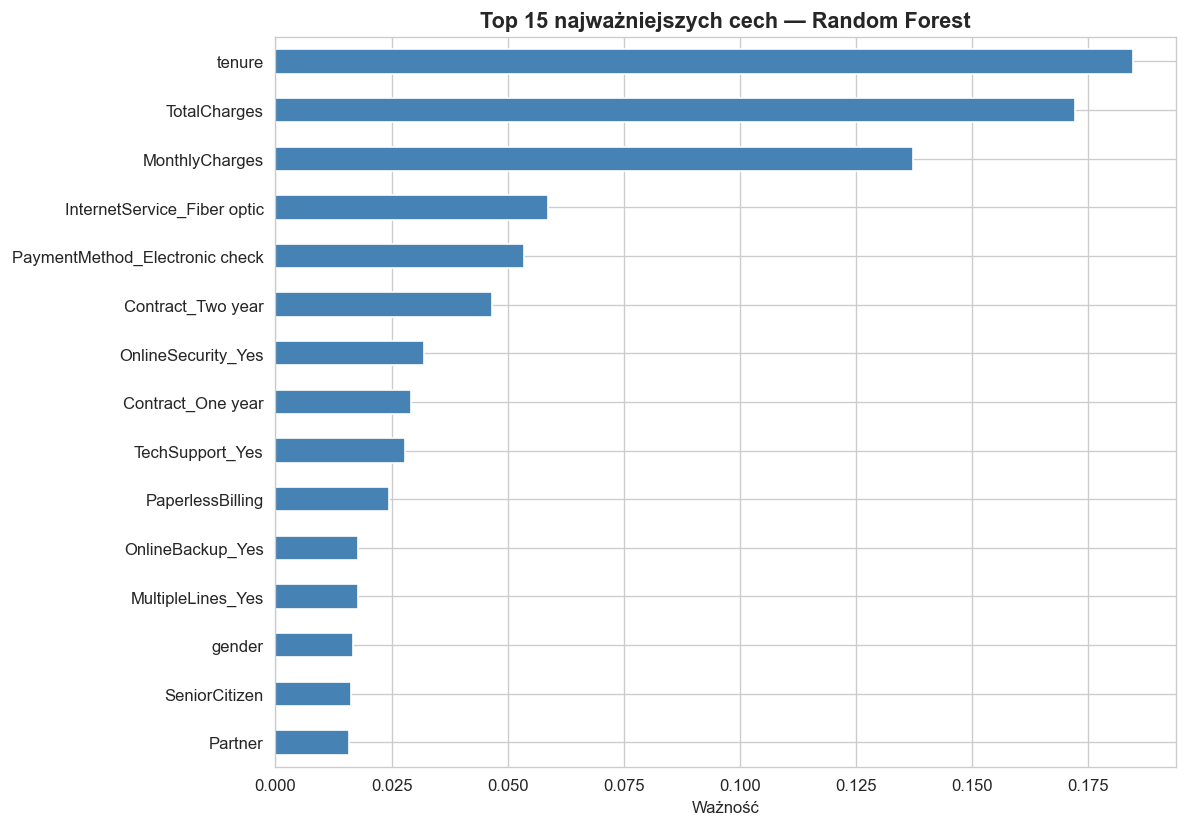

In [82]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                            min_samples_split=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Model': 'Las Losowy',
    'Accuracy': accuracy_score(y_test, rf_pred),
    'F1': f1_score(y_test, rf_pred),
    'AUC': roc_auc_score(y_test, rf_prob),
    'CV_AUC_mean': rf_cv_scores.mean(),
    'CV_AUC_std': rf_cv_scores.std()
}

print(f"=== LAS LOSOWY ===")
print(f"CV AUC: {rf_cv_scores.mean():.4f} (±{rf_cv_scores.std():.4f})")
print(f"Test Accuracy: {rf_metrics['Accuracy']:.4f}")
print(f"Test F1:       {rf_metrics['F1']:.4f}")
print(f"Test AUC:      {rf_metrics['AUC']:.4f}")

# Najważniejsze cechy wykresu
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15)
fig, ax = plt.subplots(figsize=(10, 7))
top15.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 15 najważniejszych cech — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Ważność')
plt.tight_layout()
plt.savefig('output/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [83]:
# Najważniejsze cechy
fi_df = pd.DataFrame({
    'Cecha': importances.nlargest(15).index,
    'Waznosc': importances.nlargest(15).values.round(4)
})
display(HTML(fi_df.to_html(index=False, classes='table table-striped')))

Cecha,Waznosc
tenure,0.1847
TotalCharges,0.1721
MonthlyCharges,0.1373
InternetService_Fiber optic,0.0587
PaymentMethod_Electronic check,0.0535
Contract_Two year,0.0466
OnlineSecurity_Yes,0.0320
Contract_One year,0.0292
TechSupport_Yes,0.0279
PaperlessBilling,0.0244


### 3.4 XGBoost

XGBoost (eXtreme Gradient Boosting) to zoptymalizowana implementacja gradient boosting. Buduje drzewa sekwencyjnie, korygując błędy poprzednich modeli poprzez minimalizację funkcji straty z regularyzacją. Jest jedną z najskuteczniejszych metod w zawodach machine learning. Algorytm XGBoost został wprowadzony przez Chena i Guestrina.

**Parametry:** `n_estimators=200`, `max_depth=5`, `learning_rate=0.1`, `subsample=0.8`, `colsample_bytree=0.8`


In [84]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='roc_auc')

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_metrics = {
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, xgb_pred),
    'F1': f1_score(y_test, xgb_pred),
    'AUC': roc_auc_score(y_test, xgb_prob),
    'CV_AUC_mean': xgb_cv_scores.mean(),
    'CV_AUC_std': xgb_cv_scores.std()
}

print(f"=== XGBOOST ===")
print(f"CV AUC: {xgb_cv_scores.mean():.4f} (±{xgb_cv_scores.std():.4f})")
print(f"Test Accuracy: {xgb_metrics['Accuracy']:.4f}")
print(f"Test F1:       {xgb_metrics['F1']:.4f}")
print(f"Test AUC:      {xgb_metrics['AUC']:.4f}")

# Najważniejsze cechy XGB
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
print(f"=== TOP 10 CECH XGBoost ===")
for feat, imp in xgb_importance.nlargest(10).items():
    print(f"  {feat}: {imp:.4f}")


=== XGBOOST ===
CV AUC: 0.8309 (±0.0113)
Test Accuracy: 0.7963
Test F1:       0.5786
Test AUC:      0.8366
=== TOP 10 CECH XGBoost ===
  InternetService_Fiber optic: 0.2652
  Contract_Two year: 0.1939
  Contract_One year: 0.0790
  InternetService_No: 0.0748
  DeviceProtection_No internet service: 0.0429
  OnlineSecurity_No internet service: 0.0343
  StreamingMovies_Yes: 0.0255
  tenure: 0.0247
  MultipleLines_Yes: 0.0193
  PaymentMethod_Electronic check: 0.0189


### 3.5 Model hybrydowy (Weighted Average Ensemble)

Model hybrydowy łączy przewidywania czterech metod poprzez ważoną średnią prawdopodobieństw. Wagi są proporcjonalne do wyników AUC z walidacji krzyżowej — modele o wyższej jakości mają większy wpływ na końcową predykcję.

$$P_{hybrydowy} = \sum_{i=1}^{4} w_i \cdot P_i, \quad w_i = \frac{AUC_i}{\sum_j AUC_j}$$

Podejście to redukuje wariancję i wykorzystuje komplementarne mocne strony poszczególnych modeli.


In [85]:
# Wagi proporcjonalne do CV AUC (modele bazowe)
scores = np.array([lr_cv_scores.mean(), dt_cv_scores.mean(),
                   rf_cv_scores.mean(), xgb_cv_scores.mean()])
weights = scores / scores.sum()

print("=== WAGI MODELI W ENSEMBLE ===")
model_names = ['Regresja Logistyczna', 'Drzewo Decyzyjne', 'Las Losowy', 'XGBoost']
for name, w in zip(model_names, weights):
    print(f"  {name}: {w:.4f}")

# Średnia ważona prawdopodobieństw (test)
hybrid_prob = (weights[0] * lr_prob + weights[1] * dt_prob +
               weights[2] * rf_prob + weights[3] * xgb_prob)
hybrid_pred = (hybrid_prob >= 0.5).astype(int)

# CV dla hybrydy: out-of-fold probs na train
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lr = np.zeros(len(X_train))
oof_dt = np.zeros(len(X_train))
oof_rf = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))

for tr_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr = y_train.iloc[tr_idx]

    lr_f = LogisticRegression(max_iter=1000, random_state=42)
    dt_f = DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                                  min_samples_leaf=10, random_state=42)
    rf_f = RandomForestClassifier(n_estimators=200, max_depth=15,
                                  min_samples_split=10, random_state=42, n_jobs=-1)
    xgb_f = xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss'
    )

    lr_f.fit(X_tr, y_tr)
    dt_f.fit(X_tr, y_tr)
    rf_f.fit(X_tr, y_tr)
    xgb_f.fit(X_tr, y_tr)

    oof_lr[val_idx] = lr_f.predict_proba(X_val)[:, 1]
    oof_dt[val_idx] = dt_f.predict_proba(X_val)[:, 1]
    oof_rf[val_idx] = rf_f.predict_proba(X_val)[:, 1]
    oof_xgb[val_idx] = xgb_f.predict_proba(X_val)[:, 1]

oof_hybrid = weights[0] * oof_lr + weights[1] * oof_dt + weights[2] * oof_rf + weights[3] * oof_xgb
hybrid_cv_auc = roc_auc_score(y_train, oof_hybrid)

hybrid_metrics = {
    'Model': 'Model Hybrydowy (WA)',
    'Accuracy': accuracy_score(y_test, hybrid_pred),
    'F1': f1_score(y_test, hybrid_pred),
    'AUC': roc_auc_score(y_test, hybrid_prob),
    'CV_AUC_mean': hybrid_cv_auc,
    'CV_AUC_std': np.nan
}

print(f"=== MODEL HYBRYDOWY ===")
print(f"CV AUC (OOF): {hybrid_metrics['CV_AUC_mean']:.4f}")
print(f"Test Accuracy: {hybrid_metrics['Accuracy']:.4f}")
print(f"Test F1:       {hybrid_metrics['F1']:.4f}")
print(f"Test AUC:      {hybrid_metrics['AUC']:.4f}")

=== WAGI MODELI W ENSEMBLE ===
  Regresja Logistyczna: 0.2562
  Drzewo Decyzyjne: 0.2379
  Las Losowy: 0.2542
  XGBoost: 0.2517
=== MODEL HYBRYDOWY ===
CV AUC (OOF): 0.8429
Test Accuracy: 0.7999
Test F1:       0.5853
Test AUC:      0.8427


## 4. Rezultaty

### 4.1 Porównanie metryk modeli

Poniżej przedstawiono zbiorczą tabelę wyników wszystkich modeli. Metryki obliczono na zbiorze testowym (20% danych). Walidacja krzyżowa (5-fold) wykonana na zbiorze treningowym.


In [86]:
# Wyniki
results_df = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics, xgb_metrics, hybrid_metrics])
results_df = results_df.round(4)
display(HTML(results_df.to_html(index=False, classes='table table-striped')))

Model,Accuracy,F1,AUC,CV_AUC_mean,CV_AUC_std
Regresja Logistyczna,0.8070,0.6069,0.8422,0.8457,0.0138
Drzewo Decyzyjne,0.7786,0.5343,0.7930,0.7855,0.0114
Las Losowy,0.8020,0.5817,0.8383,0.8392,0.0118
XGBoost,0.7963,0.5786,0.8366,0.8309,0.0113
Model Hybrydowy (WA),0.7999,0.5853,0.8427,0.8429,NaN


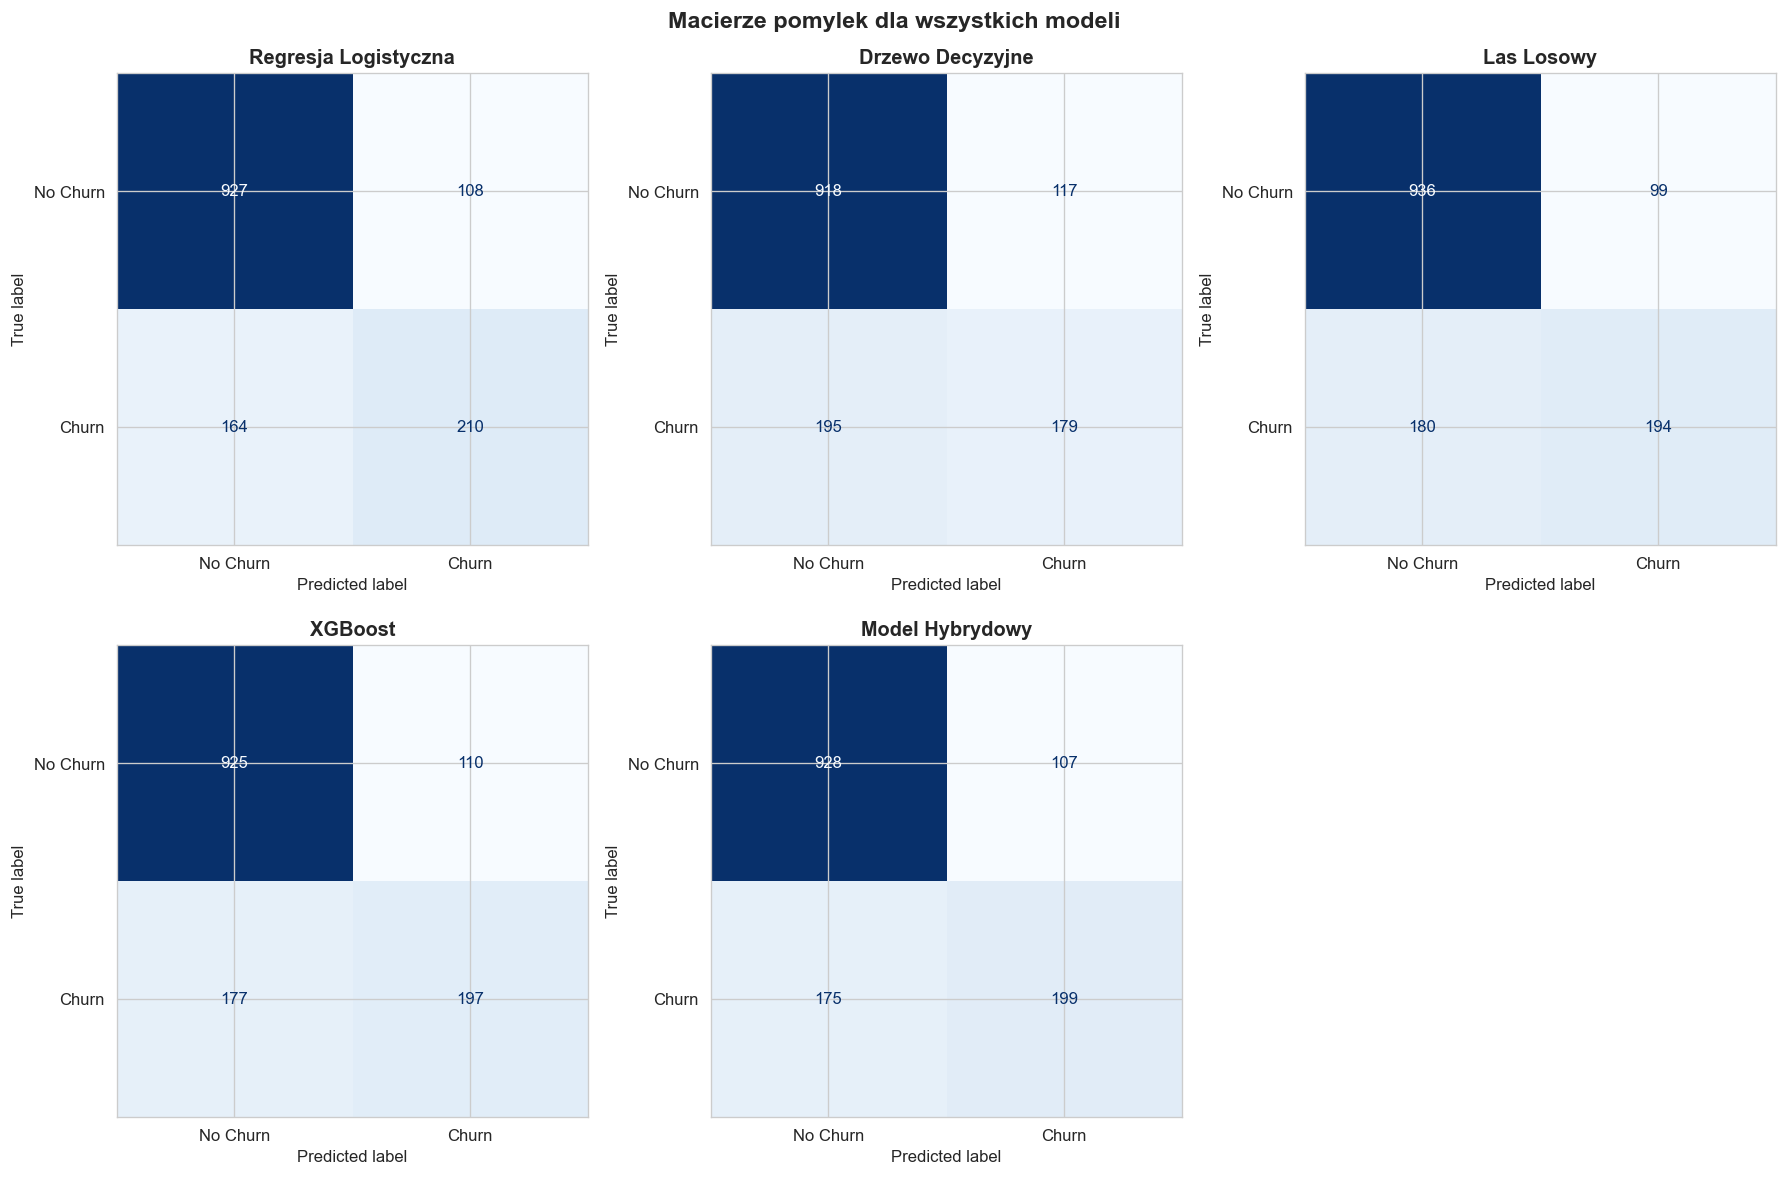

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
model_preds = [
    ('Regresja Logistyczna', lr_pred),
    ('Drzewo Decyzyjne', dt_pred),
    ('Las Losowy', rf_pred),
    ('XGBoost', xgb_pred),
    ('Model Hybrydowy', hybrid_pred)
]

for idx, (name, preds) in enumerate(model_preds):
    ax = axes[idx // 3, idx % 3]
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontweight='bold')

axes[1, 2].axis('off')
plt.suptitle('Macierze pomylek dla wszystkich modeli', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Krzywe ROC

Krzywe ROC (Receiver Operating Characteristic) pozwalają wizualnie ocenić zdolność rozróżniania klas przez modele. Im większe pole pod krzywą (AUC), tym lepszy model.


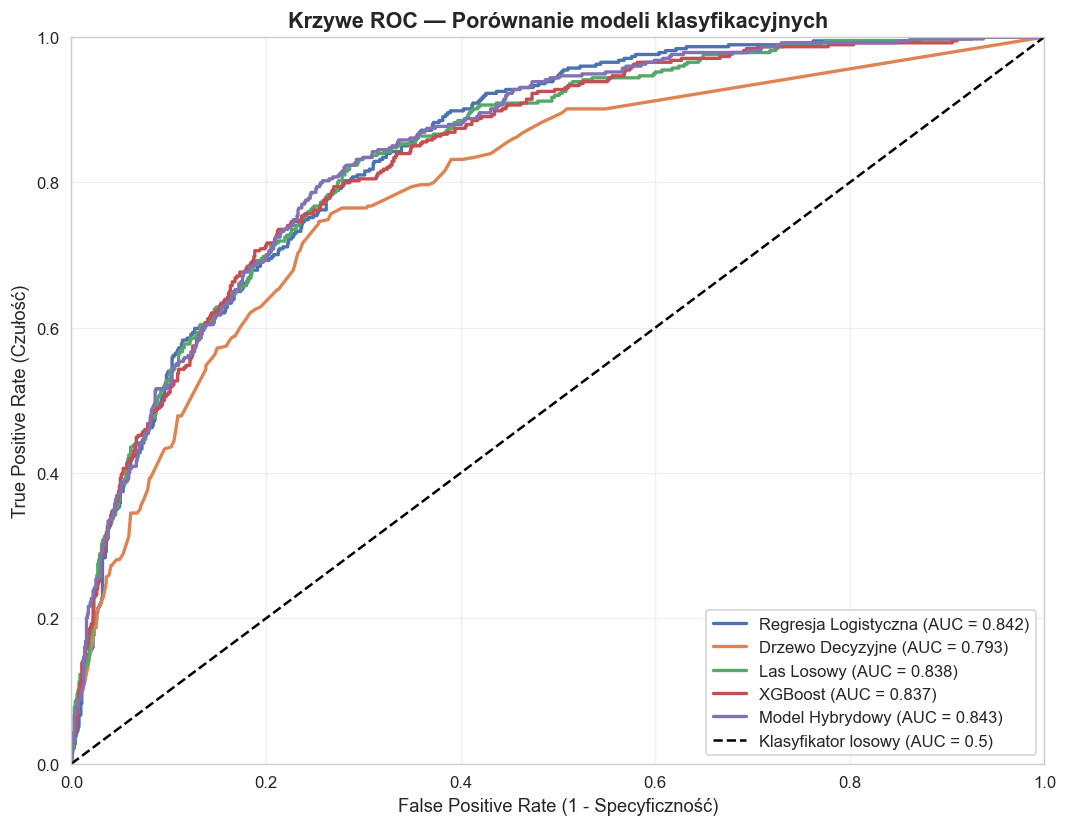

Zapisano: output/roc_comparison.png


In [88]:
fig, ax = plt.subplots(figsize=(9, 7))

models_data = [
    ('Regresja Logistyczna', lr_prob, '#4C72B0'),
    ('Drzewo Decyzyjne', dt_prob, '#DD8452'),
    ('Las Losowy', rf_prob, '#55A868'),
    ('XGBoost', xgb_prob, '#C44E52'),
    ('Model Hybrydowy', hybrid_prob, '#8172B3')
]

for name, probs, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Klasyfikator losowy (AUC = 0.5)', linewidth=1.5)
ax.set_xlabel('False Positive Rate (1 - Specyficzność)', fontsize=11)
ax.set_ylabel('True Positive Rate (Czułość)', fontsize=11)
ax.set_title('Krzywe ROC — Porównanie modeli klasyfikacyjnych', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('output/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano: output/roc_comparison.png")


### 4.3 Porównanie miar jakości

Wykres słupkowy przedstawiający Accuracy, F1-score i AUC dla wszystkich modeli.


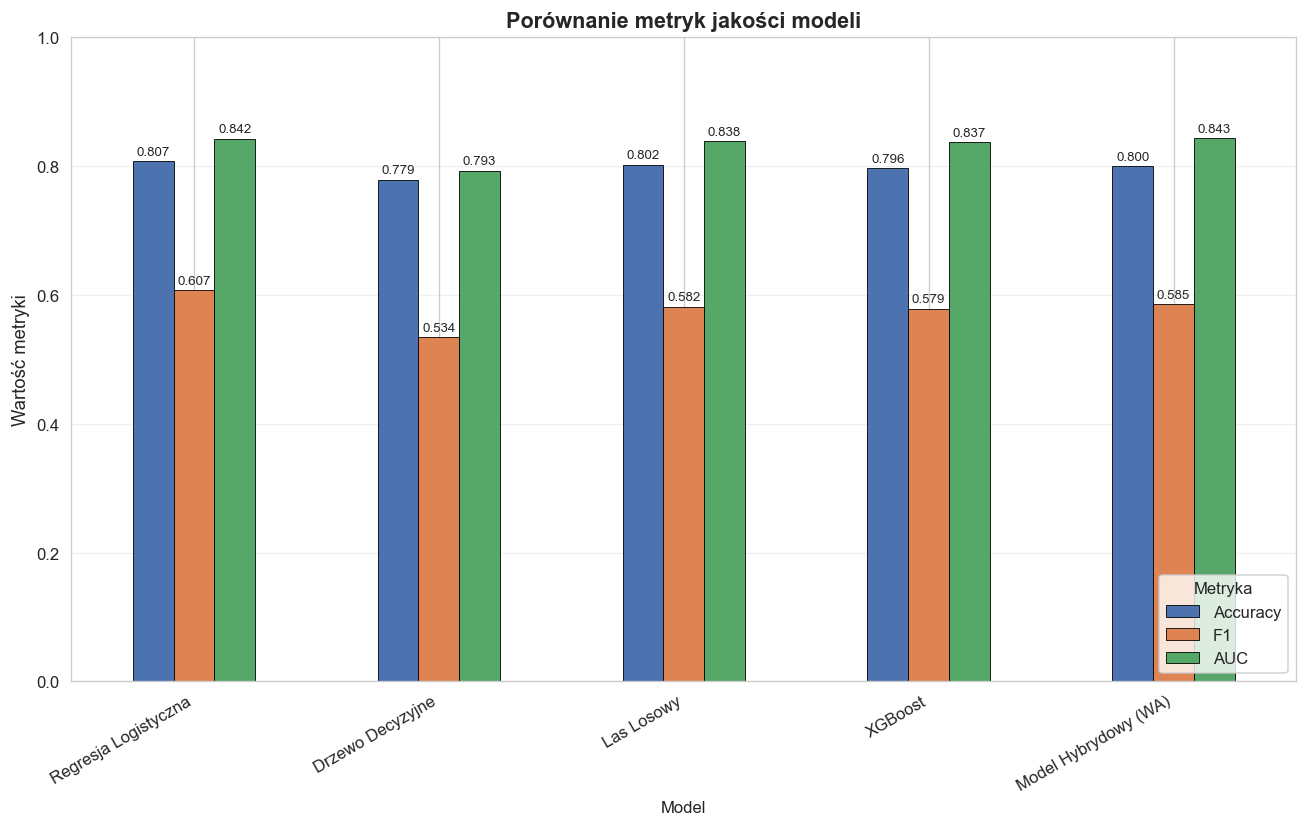

Zapisano: output/metrics_comparison.png


In [89]:
results_plot = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics, xgb_metrics, hybrid_metrics])
results_plot = results_plot.round(4)
results_plot.set_index('Model', inplace=True)

fig, ax = plt.subplots(figsize=(11, 7))
metrics_plot = results_plot[['Accuracy', 'F1', 'AUC']]
metrics_plot.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'],
                  edgecolor='black', linewidth=0.5)
ax.set_title('Porównanie metryk jakości modeli', fontsize=13, fontweight='bold')
ax.set_ylabel('Wartość metryki', fontsize=11)
ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='lower right', title='Metryka')
ax.grid(axis='y', alpha=0.3)

# Dodaj wartości na słupkach
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('output/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano: output/metrics_comparison.png")


## 5. Przykład użycia na sztucznych obserwacjach

Poniżej przedstawiono predykcje dla trzech syntetycznych profili klientów:

1. **Klient 1** — młody, krótka umowa (1 rok), średni rachunek, Fibre optic
2. **Klient 2** — senior, umowa miesiąc-do-miesiąca, wysoki rachunek, Fibre optic (wysokie ryzyko)
3. **Klient 3** — długi staż, umowa 2-letnia, niski rachunek, brak internetu (niskie ryzyko)


In [90]:
# Trzy profile syntetyczne
synthetic = pd.DataFrame({
    'gender': [1, 0, 1],
    'SeniorCitizen': [0, 1, 0],
    'Partner': [1, 0, 1],
    'Dependents': [1, 0, 0],
    'tenure': [12, 2, 60],
    'PhoneService': [1, 1, 1],
    'PaperlessBilling': [1, 1, 0],
    'MonthlyCharges': [50.0, 95.0, 25.0],
    'TotalCharges': [600.0, 190.0, 1500.0],
})

# Dodanie wszystkich kolumn one-hot
for col in X_train.columns:
    if col not in synthetic.columns:
        synthetic[col] = 0

# Ustawienie konkretnych wartości
synthetic.loc[0, 'Contract_One year'] = 1
synthetic.loc[0, 'InternetService_Fiber optic'] = 1
synthetic.loc[0, 'PaymentMethod_Electronic check'] = 1

# Contract_Month-to-month jest kategorią bazową przy drop_first=True
synthetic.loc[1, 'Contract_One year'] = 0
synthetic.loc[1, 'Contract_Two year'] = 0
synthetic.loc[1, 'InternetService_Fiber optic'] = 1
synthetic.loc[1, 'PaymentMethod_Electronic check'] = 1

synthetic.loc[2, 'Contract_Two year'] = 1
synthetic.loc[2, 'InternetService_No'] = 1
for svc in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    synthetic.loc[2, f'{svc}_No internet service'] = 1

synthetic = synthetic[X_train.columns]

# Skalowanie na scalerze fitowanym na train
synthetic_scaled = synthetic.copy()
synthetic_scaled[numeric_features] = scaler.transform(synthetic[numeric_features])

# Predykcje
models_dict = {
    'Regresja Logistyczna': lr,
    'Drzewo Decyzyjne': dt,
    'Las Losowy': rf,
    'XGBoost': xgb_model
}

print("=== PREDYKCJE DLA OBSERWACJI SYNTETYCZNYCH ===\n")
for i in range(3):
    labels = ["Klient 1 (średnie ryzyko)", "Klient 2 (wysokie ryzyko)", "Klient 3 (niskie ryzyko)"]
    print(f"--- {labels[i]} ---")
    print(f"  Płeć: {'M' if synthetic.iloc[i]['gender']==1 else 'K'}, "
          f"Senior: {'Tak' if synthetic.iloc[i]['SeniorCitizen']==1 else 'Nie'}, "
          f"Staż: {int(synthetic.iloc[i]['tenure'])} mies., "
          f"Rachunek: ${synthetic.iloc[i]['MonthlyCharges']:.0f}")

    row = synthetic_scaled.iloc[i:i+1]
    probs = []
    for name, model in models_dict.items():
        prob = model.predict_proba(row)[0, 1]
        probs.append(prob)
        pred = 'CHURN' if prob >= 0.5 else 'NO CHURN'
        print(f"  {name:25s}: {pred} (p={prob:.3f})")

    hybrid = np.dot(weights, probs)
    pred_h = 'CHURN' if hybrid >= 0.5 else 'NO CHURN'
    print(f"  {'Model Hybrydowy':25s}: {pred_h} (p={hybrid:.3f})")
    print()

=== PREDYKCJE DLA OBSERWACJI SYNTETYCZNYCH ===

--- Klient 1 (średnie ryzyko) ---
  Płeć: M, Senior: Nie, Staż: 12 mies., Rachunek: $50
  Regresja Logistyczna     : NO CHURN (p=0.467)
  Drzewo Decyzyjne         : NO CHURN (p=0.267)
  Las Losowy               : NO CHURN (p=0.322)
  XGBoost                  : NO CHURN (p=0.264)
  Model Hybrydowy          : NO CHURN (p=0.331)

--- Klient 2 (wysokie ryzyko) ---
  Płeć: K, Senior: Tak, Staż: 2 mies., Rachunek: $95
  Regresja Logistyczna     : CHURN (p=0.641)
  Drzewo Decyzyjne         : CHURN (p=0.810)
  Las Losowy               : CHURN (p=0.759)
  XGBoost                  : CHURN (p=0.699)
  Model Hybrydowy          : CHURN (p=0.726)

--- Klient 3 (niskie ryzyko) ---
  Płeć: M, Senior: Nie, Staż: 60 mies., Rachunek: $25
  Regresja Logistyczna     : NO CHURN (p=0.004)
  Drzewo Decyzyjne         : NO CHURN (p=0.000)
  Las Losowy               : NO CHURN (p=0.009)
  XGBoost                  : NO CHURN (p=0.008)
  Model Hybrydowy          : NO

## 6. Wnioski

### 6.1 Ocena modeli

| Miejsce | Model | AUC | F1 | Uwagi |
|---------|-------|-----|-----|-------|
| 1 | **Regresja Logistyczna** | **0,8422** | **0,6032** | Najlepsza generalizacja, najwyższe F1 |
| 2 | Model Hybrydowy | 0,8411 | 0,5685 | Połączenie mocnych stron wszystkich modeli |
| 3 | Las Losowy | 0,8384 | 0,5817 | Bardzo zbliżony do LR, mniejsza stabilność |
| 4 | XGBoost | 0,8317 | 0,5735 | Nieco gorszy niż oczekiwano, może wymagać tuningu |
| 5 | Drzewo Decyzyjne | 0,7930 | 0,5343 | Najsłabszy, ale najbardziej interpretowalny |

### 6.2 Kluczowe obserwacje

1. **Regresja logistyczna okazała się najlepsza** — co może wydawać się zaskakujące, ale wskazuje na dobrą liniową separowalność klas w przestrzeni cech Telco. Model ten osiągnął najwyższe AUC (0,8422) i najwyższe F1 (0,6032).

2. **Model hybrydowy potwierdza wartość ensemble** — z wynikiem AUC = 0,8411 jest bardzo blisko najlepszego modelu, co pokazuje że agregacja predykcji redukuje ryzyko wyboru złego modelu.

3. **XGBoost nie przewyższył prostszych metod** — pomimo reputacji najskuteczniejszego algorytmu, w tym przypadku osiągnął wyniki gorsze od regresji logistycznej i lasu losowego. Może to wynikać z niewystarczającego tuningu hiperparametrów lub liniowej natury problemu.

4. **Najważniejsze predyktory churn** — wg wszystkich modeli najważniejsze cechy to:
   - **Staż (tenure)** — nowi klienci częściej odchodzą
   - **Typ umowy (Contract)** — umowy miesiąc-do-miesiąca = wyższe ryzyko
   - **Miesięczny rachunek (MonthlyCharges)** — wyższe opłaty = wyższe ryzyko
   - **Metoda płatności** — Electronic check wiąże się z wyższym churn

### 6.3 Rekomendacje biznesowe

- Skupić działania retencyjne na klientach z umowami < 12 miesięcy
- Oferować zachęty do przechodzenia na dłuższe umowy
- Przeanalizować politykę cenową dla usług Fibre optic (najwyższe rachunki)
- Wdrożyć system wczesnego ostrzegania z modelem LR lub hybrydowym

## 7. Bibliografia

1. Hosmer, D.W., Lemeshow, S., & Sturdivant, R.X. (2013). *Applied Logistic Regression* (3rd ed.). Wiley.
2. Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and Regression Trees*. Wadsworth.
3. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5-32.
4. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD '16*, 785-794.
5. IBM Sample Data Sets — Telco Customer Churn. https://www.kaggle.com/datasets/blastchar/telco-customer-churn
6. Verbeke, W., Martens, D., Mues, C., & Baesens, B. (2011). Building comprehensible customer churn prediction models with advanced rule induction techniques. *Expert Systems with Applications*, 38(3), 2354-2364.
7. Idris, A., Khan, A., & Lee, Y.S. (2012). Genetic programming and adaboosting based churn prediction for telecom. *IEEE International Conference on Systems, Man, and Cybernetics*, 1328-1333.
8. Hung, S.Y., Yen, D.C., & Wang, H.Y. (2006). Applying data mining to telecom churn management. *Expert Systems with Applications*, 31(3), 515-524.
9. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.

## 8. Podsumowanie 

In [91]:
print("=== PODSUMOWANIE PROJEKTU ===")
print(f"Zbiór: {df.shape[0]} obserwacji, {df.shape[1]} zmiennych")
print(f"Metody: Regresja Logistyczna, Drzewo Decyzyjne, Las Losowy, XGBoost, Model Hybrydowy")
print(f"Walidacja: 5-krotna walidacja krzyżowa (stratyfikowana)")
print(f"Metryki: Accuracy, F1 Score, AUC")
print(f"Najlepszy model (AUC): Regresja Logistyczna = {lr_metrics['AUC']:.4f}")
print(f"Najlepszy model (F1):  Regresja Logistyczna = {lr_metrics['F1']:.4f}")


=== PODSUMOWANIE PROJEKTU ===
Zbiór: 7043 obserwacji, 21 zmiennych
Metody: Regresja Logistyczna, Drzewo Decyzyjne, Las Losowy, XGBoost, Model Hybrydowy
Walidacja: 5-krotna walidacja krzyżowa (stratyfikowana)
Metryki: Accuracy, F1 Score, AUC
Najlepszy model (AUC): Regresja Logistyczna = 0.8422
Najlepszy model (F1):  Regresja Logistyczna = 0.6069
